# Exercise 1 - 2-faction party

<img src="ex1.png">

## Imports

In [1]:
import pickle
import networkx as nx
import random
import numpy as np
import os
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd
import pytensor.tensor as pt

## Set Seed for determinism

In [3]:
SEED = 23
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
rng = np.random.default_rng(SEED)

## Data Visualization (Structure)

In [4]:
G = pickle.load(open('ex_1_graph.pickle', 'rb'))

# Basic information about the graph
print("Graph object type:", type(G))
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Graph is directed:", G.is_directed()) # Important that is not directed

# Check if there are 2 factions present
factions = sorted(set(attrs["faction"] for _, attrs in G.nodes(data=True)))
print("\nFactions present in the network:", factions)
print()

# Check nodes + edges with attributes
for node, attributes in list(G.nodes(data=True))[:3]:
    print(f"Node {node}: {attributes}")
print()
for u, v, attributes in list(G.edges(data=True))[:3]:
    print(f"Edge ({u}, {v}): {attributes}")

Graph object type: <class 'networkx.classes.graph.Graph'>
Number of nodes: 60
Number of edges: 498
Graph is directed: False

Factions present in the network: ['A', 'B']

Node 0: {'name': 'Eric Hill', 'faction': 'A'}
Node 1: {'name': 'Neil Ali', 'faction': 'A'}
Node 2: {'name': 'Marcus Nichols', 'faction': 'A'}

Edge (0, 1): {'messages': 21}
Edge (0, 2): {'messages': 37}
Edge (0, 3): {'messages': 33}


Red -> Faction A
Blue -> Faction B


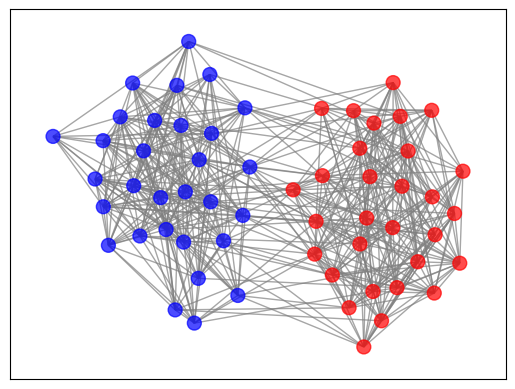

In [5]:
# Draw the graph to visualize its structure
pos = nx.spring_layout(G, seed=SEED + 1)
faction_list = ['A', 'B']
colors = ['red' if G.nodes[node]['faction'] == faction_list[0] else 'blue' for node in G.nodes()]

print("Red -> Faction A")
print("Blue -> Faction B")
nx.draw_networkx(G, pos=pos, with_labels=False, node_color=colors, node_size=100, edge_color='gray', alpha=0.7)

## Data Visualization (Edges width depends on the volume of messages)

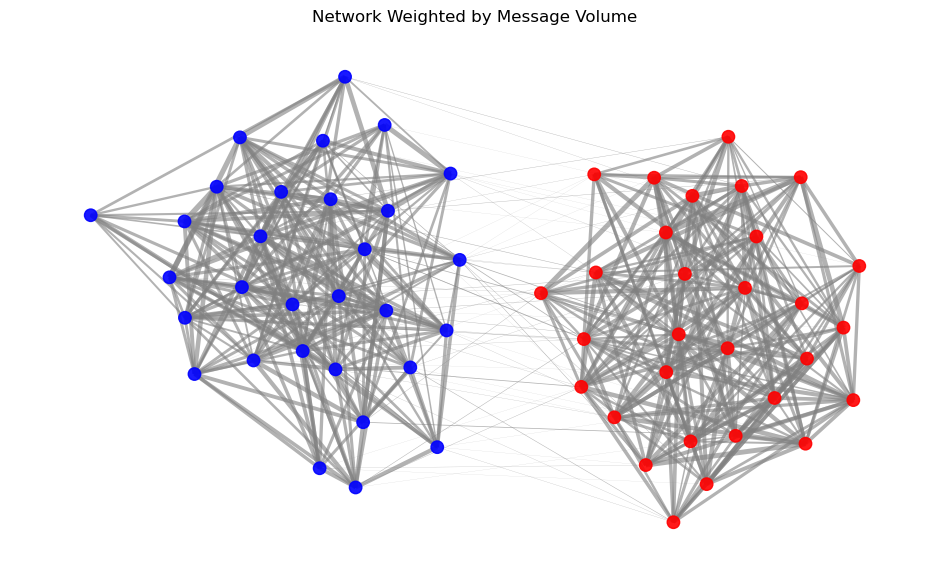

Max messages on an edge: 45


In [6]:
# Extract edge messages
edge_messages = [G[u][v]["messages"] for u, v in G.edges()]

# Normalize edge widths for plotting
max_weight = max(edge_messages)
edge_widths = [(w / max_weight) * 4 for w in edge_messages]
plt.figure(figsize=(12, 7))

# Draw nodes
nx.draw_networkx_nodes(G,pos=pos,node_size=80,node_color=colors,alpha=0.9)
# Draw weighted edges
nx.draw_networkx_edges(G,pos,edge_color="gray",width=edge_widths,alpha=0.6)

plt.title("Network Weighted by Message Volume")
plt.axis("off")
plt.show()
print("Max messages on an edge:", max_weight)


### Interpretation (after seeing the graph)
1. The 2 factions form a dense internal communication (influence stays primarily within factions)
2. There is a limited cross-faction communication (shown by the narrow edges)

## Data Prep 

In [7]:
# Create indexed node list and count
nodes = list(G.nodes())
N = len(nodes)
print("N =", N)

# Create faction array: 0 for 'A', 1 for 'B'
faction = np.array([0 if G.nodes[i]["faction"] == "A" else 1 for i in range(N)],dtype=int)
print("Faction counts:", np.bincount(faction))
print("Remark: Factions are balanced in this dataset.")

# Extract data into arrays for modeling
src = []
dst = []
y = []

for u, v, data in G.edges(data=True):
    src.append(u)
    dst.append(v)
    y.append(data["messages"])

src = np.array(src, dtype=int)
dst = np.array(dst, dtype=int)
y = np.array(y, dtype=float)

print("\nE(observed edges)=", len(y))
print("Messages summary:")
print(pd.Series(y).describe())

# Sanity check: within vs cross-faction edges
same_faction = (faction[src] == faction[dst])

print("Within-faction edges:", int(same_faction.sum()))
print("Cross-faction edges:", int((~same_faction).sum()))

print("\nAverage messages per edge:")
print("within-faction:", y[same_faction].mean() if same_faction.any() else None)
print("cross-faction:", y[~same_faction].mean() if (~same_faction).any() else None)

N = 60
Faction counts: [30 30]
Remark: Factions are balanced in this dataset.

E(observed edges)= 498
Messages summary:
count    498.000000
mean      22.644578
std        9.774324
min        1.000000
25%       18.250000
50%       25.000000
75%       29.000000
max       45.000000
dtype: float64
Within-faction edges: 437
Cross-faction edges: 61

Average messages per edge:
within-faction: 25.480549199084667
cross-faction: 2.3278688524590163


### Modelling Assumptions

The network model is modeled as an **UNDIRECTED GRAPH** --> messages represent mutual interaction between 2 politicians (no sender/receiver)

Result ==> each edge m_ij will be treated simetrically in the latent space model 

Other details:
- 498 observed edges out of 1770 possible dyads
- most communication happens between factions
- factions are perfectly balanced (A = 30 ; B =30)


## Build dyad data (including zero-message pairs)

1. We include all unordered node pairs (i, j).
2. If an edge is present, we use its observed message count. Otherwise we record 0 messages.

In [8]:
# Build a lookup table for message counts on observed edges
msg_lookup = {}

for u, v, data in G.edges(data=True):
    i, j = (u, v) if u < v else (v, u)  # enforce i < j for undirected pairs
    msg_lookup[(i, j)] = data["messages"]

# Build full dyad arrays (all i<j)
dyad_i = []
dyad_j = []
dyad_y = []
dyad_same = []

for i in range(N):
    for j in range(i + 1, N):
        dyad_i.append(i)
        dyad_j.append(j)
        dyad_y.append(msg_lookup.get((i, j), 0))  # 0 if no edge => means no message
        dyad_same.append(int(faction[i] == faction[j]))

dyad_i = np.array(dyad_i, dtype=int)
dyad_j = np.array(dyad_j, dtype=int)
dyad_y = np.array(dyad_y, dtype=float)
dyad_same = np.array(dyad_same, dtype=int)

print("Total dyads (all pairs i<j):", len(dyad_y))
print("Nonzero dyads (edges):", int((dyad_y > 0).sum()))
print("Zero dyads (no interaction):", int((dyad_y == 0).sum()))

print("\nAverage messages per dyad:")
print("overall:", dyad_y.mean())
print("same faction:", dyad_y[dyad_same == 1].mean())
print("different factions:", dyad_y[dyad_same == 0].mean())

Total dyads (all pairs i<j): 1770
Nonzero dyads (edges): 498
Zero dyads (no interaction): 1272

Average messages per dyad:
overall: 6.371186440677966
same faction: 12.798850574712644
different factions: 0.15777777777777777


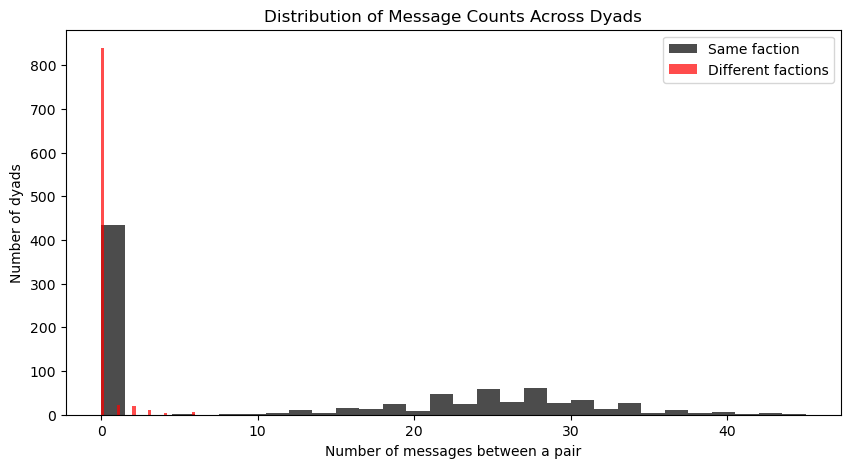

In [9]:
# plot histogram of dyad messages
y_same = dyad_y[dyad_same == 1]
y_diff = dyad_y[dyad_same == 0]

plt.figure(figsize=(10, 5))

plt.hist(y_same, bins=30, alpha=0.7, label="Same faction", color='black')
plt.hist(y_diff, bins=30, alpha=0.7, label="Different factions", color='red')

plt.xlabel("Number of messages between a pair")
plt.ylabel("Number of dyads")
plt.title("Distribution of Message Counts Across Dyads")
plt.legend()
plt.show()

## 1. Baseline Latent Distance Model (LS + Poisson)

We start with a baseline latent distance model following the framework of
Hoff, Raftery, and Handcock (2002).

Each node $(i)$ is assigned a latent position $( \mathbf{z}_i \in \mathbb{R}^2 )$.
For each dyad \( (i, j) \), the observed number of messages $( y_{ij} )$ is modeled as:

$
y_{ij} \sim \text{Poisson}(\lambda_{ij}), \qquad
\log \lambda_{ij} = \alpha - \lVert \mathbf{z}_i - \mathbf{z}_j \rVert
$

where $( \alpha )$ controls the overall communication intensity and the expected
number of messages decreases with latent distance (Euclidean).

This baseline model provides a simple, interpretable starting point to assess
how much of the network structure can be explained by latent geometry.

In [9]:
coords = {
    "node": np.arange(N),
    "dim": np.arange(2),
    "dyad": np.arange(len(dyad_y)),
}

with pm.Model(coords=coords) as baseline_model:

    # Data
    i_idx = pm.Data("i_idx", dyad_i, dims="dyad")
    j_idx = pm.Data("j_idx", dyad_j, dims="dyad")
    y_obs = pm.Data("y_obs", dyad_y, dims="dyad")

    # Priors
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)
    z = pm.Normal("z", mu=0.0, sigma=1.0, dims=("node", "dim"))

    # Latent distances
    zi = z[i_idx]
    zj = z[j_idx]
    distance = pt.sqrt(pt.sum((zi - zj) ** 2, axis=1))

    # Poisson rate
    log_lambda = alpha - distance
    lbd = pm.Deterministic("lambda", pt.exp(log_lambda), dims="dyad")

    # Likelihood
    y = pm.Poisson("y", mu=lbd, observed=y_obs, dims="dyad")

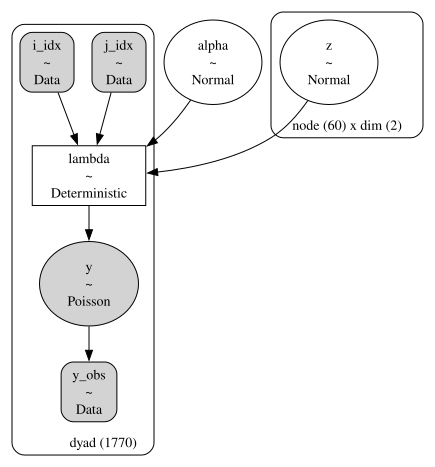

In [10]:
pm.model_to_graphviz(baseline_model)

In [11]:
with baseline_model:
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=SEED
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, z]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 65 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


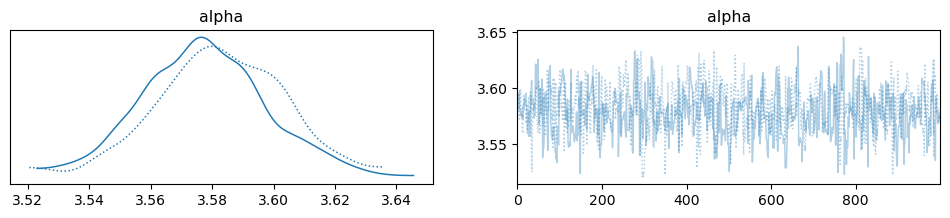

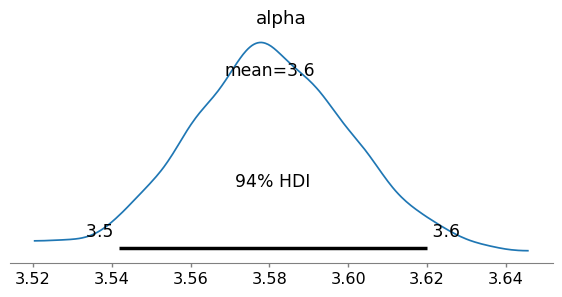

In [12]:
az.plot_trace(idata, var_names=["alpha"])
az.plot_posterior(idata, var_names=["alpha"], figsize=(7, 3))
plt.show()
plt.close()

Sampling: [y]


Output()

<Axes: xlabel='y'>

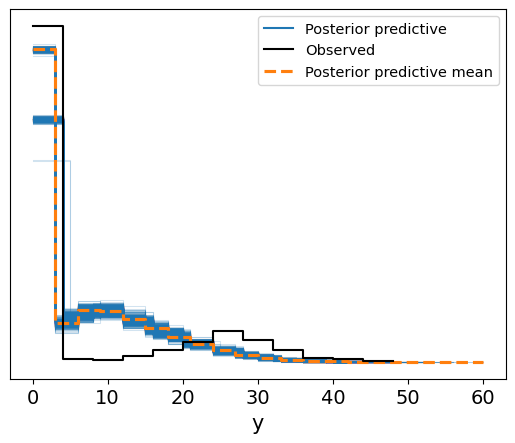

In [13]:
with baseline_model:
    idata_ppc = pm.sample_posterior_predictive(
        idata,
        var_names=["y"],     
        random_seed=SEED,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_ppc,
    var_names=["y"],
    num_pp_samples=500
)

### Latent Space Plot -> Baseline

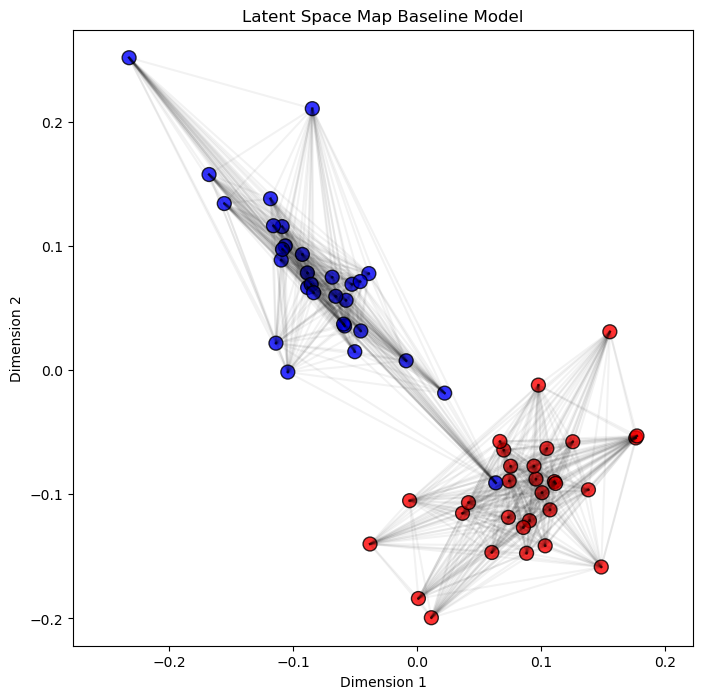

In [14]:
z_post = idata.posterior["z"].mean(dim=["chain", "draw"]).values

plt.figure(figsize=(8, 8))
colors = ['red' if f == 0 else 'blue' for f in faction]
plt.scatter(z_post[:, 0], z_post[:, 1], c=colors, s=100, alpha=0.8, edgecolors='k')

count = 0
for u, v in zip(dyad_i, dyad_j):
    if faction[u] == faction[v]:
        plt.plot([z_post[u, 0], z_post[v, 0]], [z_post[u, 1], z_post[v, 1]], 
                 'k-', alpha=0.05)
        count += 1

plt.title("Latent Space Map Baseline Model")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.axis('equal')
plt.show()

## 1. Baseline Latent Distance Model (LS + Poisson) - Evaluation

**1. Convergence Diagnostics:**
-  Model converges well (R-hat = 1.01, stable traces).  
-  Inference for parameters is reliable.  

**2. Posterior Predictive Check:**
- Posterior predictive checks show poor fit.  
    - Zero-message dyads are **underpredicted**. (it lacks a mechanism for the politicians that dont speak)
    - Low positive message counts are **overpredicted**. The model predicts a cluster of values around $y \approx 10$, failing to capture the distinct separation between the "Silent Majority" ($y=0$) and the "Active Conversation" ($y \approx 25$).

**3. Latent Space Visualization**
- the latent map shows separation (the distance is relevent) but I think it's not sufficient because I think the model is struggling to explain the zeros using distance alone.

**Conclusion:**
- Latent distance alone is insufficient to explain the network because the zero-message dyads influences it's logic.  
- This motivates extending the model with more structure. In the next model I try to solve the Zero-message problem
- After searching a bit more the structure of the model presented in the visualization looks like Zero-inflated Poisson https://en.wikipedia.org/wiki/Zero-inflated_model

## 2. Latent Distance Model Zero-Inflated Poisson (LS-ZIP)

- To address the underprediction of zeros in the baseline model, we introduce a **Zero-Inflated** mechanism and hopefully make the latent space meaningfull.

#### So the model becomes a mixture of 2 processes:
- Structural Zeros (The Wall) --> a process that determines if a pair can comunicate at all
- Count Process (The Conversation) -> If they *can* communicate, the number of messages is modeled as a Poisson process driven by **Latent Distance**

$$
y_{ij} \sim \text{ZIPoisson}(\psi_{ij}, \lambda_{ij})
$$


**The Zero Component ($\psi$):**
$$ \text{logit}(\psi_{ij}) = \gamma_0 + \gamma_{\text{faction}} \cdot \mathbb{I}(\text{SameFaction}) $$
*(If they are in the same faction, the probability of "structural silence" should drop.)*

**The Count Component ($\lambda$):**
$$ \log(\lambda_{ij}) = \alpha - \lVert \mathbf{z}_i - \mathbf{z}_j \rVert $$
*(Same as in the baseline.)*

<img src=https://www.pymc.io/projects/docs/en/latest/_images/pymc-ZeroInflatedPoisson-1.png>

In [10]:
coords = {
    "node": np.arange(N),
    "dim": np.arange(2),
    "dyad": np.arange(len(dyad_y)),
}

with pm.Model(coords=coords) as lszip_model:

    # Data
    i_idx = pm.Data("i_idx", dyad_i, dims="dyad")
    j_idx = pm.Data("j_idx", dyad_j, dims="dyad")
    y_obs = pm.Data("y_obs", dyad_y, dims="dyad")
    is_same = pm.Data("is_same", dyad_same, dims="dyad") # Indicates if dyad is same faction (new addition)

    # 1. Zero-Inflation Process (Psi)
    # controls the prob of being a 0
    # Priors
    gamma0 = pm.Normal("gamma0", mu=0.0, sigma=1.5)
    gamma_f = pm.Normal("gamma_f", mu=0.0, sigma=1.5) # Expected negative (same faction -> less silence)

    logit_psi = gamma0 + (gamma_f * is_same) 
    psi = pm.math.invlogit(logit_psi)

    # 2. Count Process (Lambda)
    # number of messages when not a structural zero
    # Priors
    z = pm.Normal("z", mu=0.0, sigma=1.0, dims=("node", "dim"))
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)

    # Calculate Euclidean distances
    zi = z[i_idx]
    zj = z[j_idx]
    distance = pt.sqrt(pt.sum((zi - zj)**2, axis=1) + 1e-5)

    # Poisson rate driven by distance (same as Baseline)
    log_lambda = alpha - distance
    lbd = pm.math.exp(log_lambda)

    # Likelihood
    y = pm.ZeroInflatedPoisson(
        "y", 
        psi=psi, 
        mu=lbd, 
        observed=y_obs, 
        dims="dyad"
    )

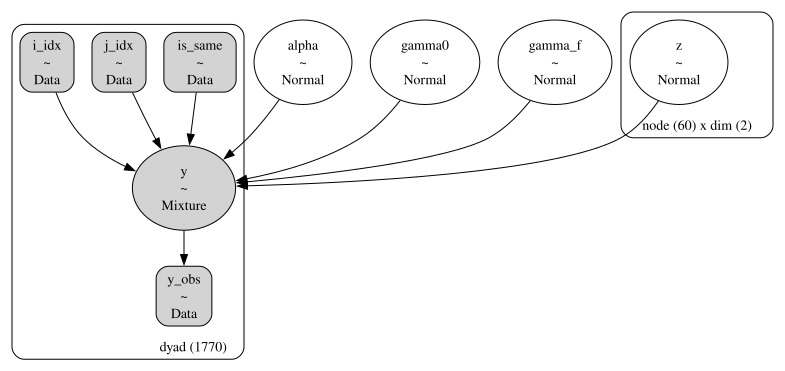

In [11]:
pm.model_to_graphviz(lszip_model)

In [12]:
with lszip_model:
    idata_lszip = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [gamma0, gamma_f, z, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 170 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


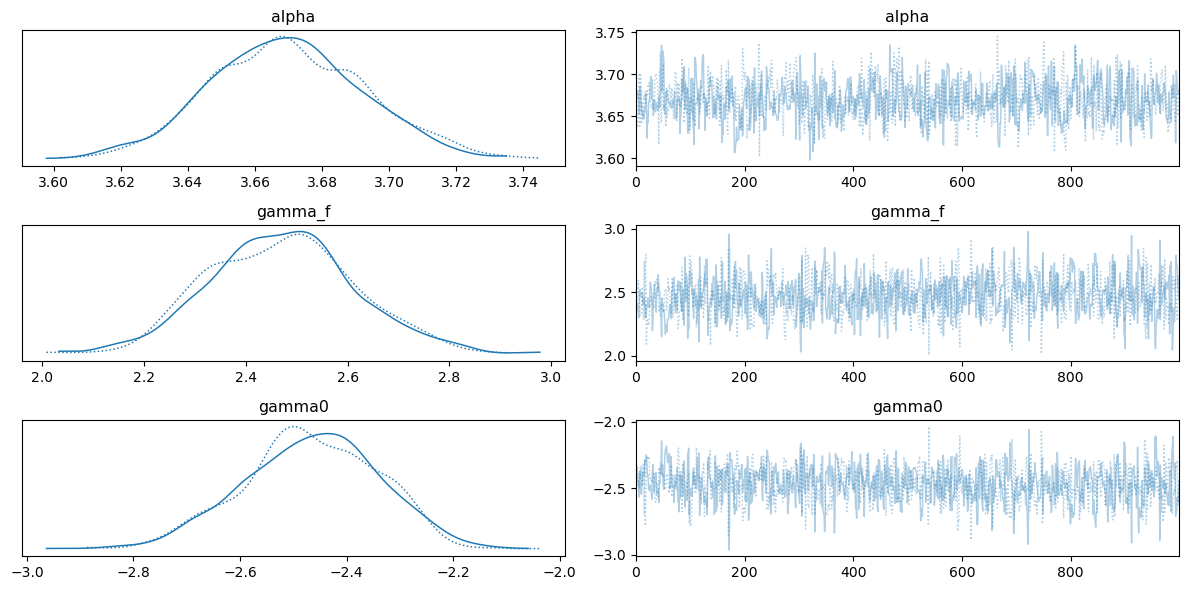

In [13]:
az.plot_trace(idata_lszip, var_names=["alpha", "gamma_f", "gamma0"])
plt.tight_layout()
plt.show()

In [14]:
summary_lszip = az.summary(idata_lszip, var_names=["gamma0","gamma_f","alpha"])
print(summary_lszip)

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
gamma0  -2.467  0.130  -2.705   -2.238      0.004    0.003     871.0   
gamma_f  2.471  0.146   2.210    2.750      0.005    0.004     867.0   
alpha    3.670  0.023   3.629    3.716      0.001    0.001     764.0   

         ess_tail  r_hat  
gamma0      961.0   1.01  
gamma_f    1086.0   1.01  
alpha       979.0   1.00  


Sampling: [y]


Output()

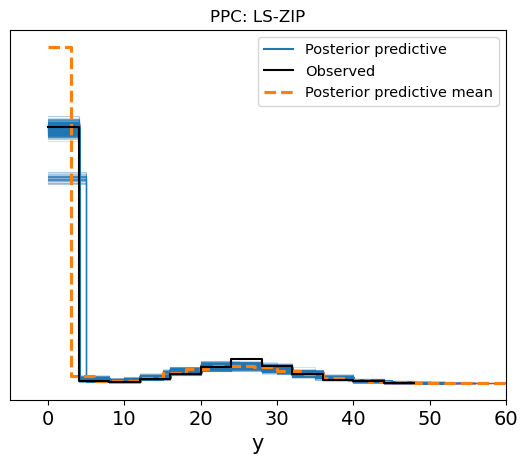

In [15]:
with lszip_model:
    ppc_lszip = pm.sample_posterior_predictive(
        idata_lszip,
        var_names=["y"],
        random_seed=SEED,
        extend_inferencedata=True
    )

az.plot_ppc(ppc_lszip, num_pp_samples=500)
plt.xlim(-5, 60)
plt.title("PPC: LS-ZIP")
plt.show()

### Latent Space Plot -> LSZIP

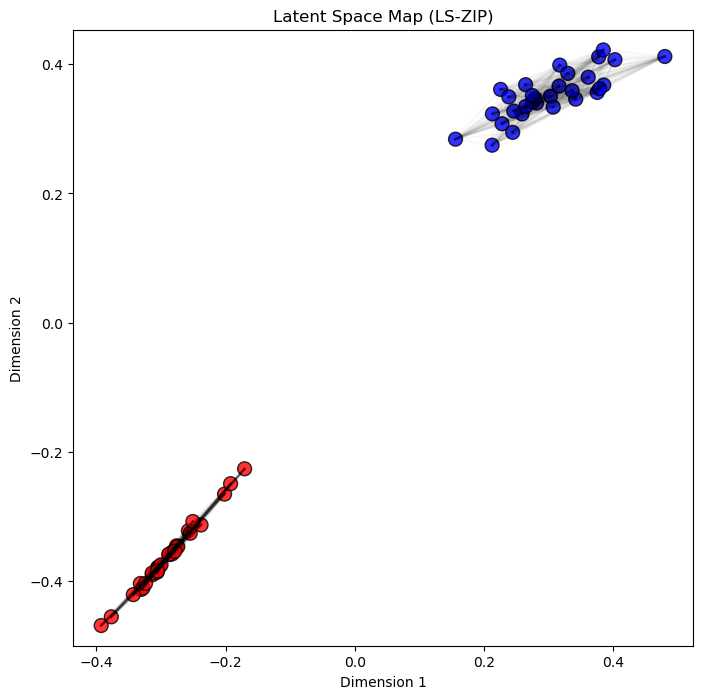

In [16]:
z_post = idata_lszip.posterior["z"].mean(dim=["chain", "draw"]).values

plt.figure(figsize=(8, 8))
colors = ['red' if f == 0 else 'blue' for f in faction]

plt.scatter(z_post[:, 0], z_post[:, 1], c=colors, s=100, alpha=0.8, edgecolors='k')

count = 0
for u, v in zip(dyad_i, dyad_j):
    if faction[u] == faction[v]: # Only draw a few same-faction links
        plt.plot([z_post[u, 0], z_post[v, 0]], [z_post[u, 1], z_post[v, 1]], 
                 'k-', alpha=0.03)
        count += 1

plt.title("Latent Space Map (LS-ZIP)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.axis('equal')
plt.show()

### Sanity Checks

In [17]:

dist_post = np.sqrt(np.sum((z_post[dyad_i] - z_post[dyad_j])**2, axis=1))

# Split by faction status
dist_same = dist_post[dyad_same == 1]
dist_diff = dist_post[dyad_same == 0]

print("Latent Space Analysis")
print(f"Mean Latent Distance (Same Faction):      {dist_same.mean():.4f}")
print(f"Mean Latent Distance (Different Faction): {dist_diff.mean():.4f}")

ratio = dist_diff.mean() / dist_same.mean()
print(f"Segregation Ratio (Diff / Same):          {ratio:.2f}x")
print("The model successfully pushed faction enemies apart and pulled allies together in the latent space.")

Latent Space Analysis
Mean Latent Distance (Same Faction):      0.0879
Mean Latent Distance (Different Faction): 0.9285
Segregation Ratio (Diff / Same):          10.56x
The model successfully pushed faction enemies apart and pulled allies together in the latent space.


In [18]:
y_pred = ppc_lszip.posterior_predictive["y"]
zeros_obs = (dyad_y == 0).mean()
zeros_pred = (y_pred == 0).mean(dim=["chain", "draw", "dyad"]).values

print("\nZero-Inflation Analysis")
print(f"Observed % of Zeros:  {zeros_obs:.1%}")
print(f"Predicted % of Zeros: {zeros_pred:.1%}")


Zero-Inflation Analysis
Observed % of Zeros:  71.9%
Predicted % of Zeros: 71.8%


## 2. Latent Distance Model Zero-Inflated Poisson (LS-ZIP) - Evaluation

**1. Convergence Diagnostics:**
-  Model converges well (R-hat = 1.00/1.01, stable traces).  
-  reliable inference

**2. Posterior Predictive Check:**
- Zero-message dyads -> Success! This new model captures well the politicians that don't speak. Observed % of Zeros:  71.9%/ Predicted % of Zeros: 71.8%
- Poitive message counts are now better located and almost models the observed data perfectly (there is just a slight mismatch)

**3. Latent Space Visualization**
- the latent map shows very strong separation between the 2 factions.
- The model successfully pushed opponents far apart (High Segregation Ratio 10.56x),which means latent space now effectively organizes the internal structure of the factions rather than just struggling to explain the zeros.

**Conclusion:**
- the LS-ZIP is the winning model and this is what I will use to answer the questions

## Q1: Who is the most influential politician from each faction?

I think an "influential politician" is not the one that sends the most messages (which could be just 2 politicians spamming each other), but the one that is the "core" of the faction.

It is a politician that mantains active/meaningful connections with a lot of faction members. (meaningful = a good number of messages)

**Translation to Latent Space**
- the expected interaction volume drops as distance increases

==> the most influential politician is the one located an the **centroid of the cluster**


In [19]:
def get_central_node(target_faction):
    indices = np.where(faction == target_faction)[0]
    coords = z_post[indices]
    
    # calculate the (Centroid) of the cluster
    centroid = coords.mean(axis=0)
    
    # find the node closest to this centroid
    dists_to_center = np.sqrt(np.sum((coords - centroid)**2, axis=1))
    best_idx = np.argmin(dists_to_center)
    
    return indices[best_idx]

degrees = dict(G.degree(weight='messages'))
data_A = max([n for n in G.nodes if faction[n] == 0], key=lambda x: degrees[x])
data_B = max([n for n in G.nodes if faction[n] == 1], key=lambda x: degrees[x])

influential_A = get_central_node(0) # Faction A
influential_B = get_central_node(1) # Faction B

print(f"Most messages sent (Faction A): Node {data_A}, Messages Sent: {degrees[data_A]}")
print(f"Most Influential (Faction A): Node {influential_A}, Messages Sent: {degrees[influential_A]}")
print()
print(f"Most messages sent (Faction B): Node {data_B}, Messages Sent: {degrees[data_B]}")
print(f"Most Influential (Faction B): Node {influential_B}, Messages Sent: {degrees[influential_B]}")

print("\nNote: The models choice of influential nodes differs from the highest message senders")
print("This shows the models ability to identify central figures in the latent space beyond message volume.")


Most messages sent (Faction A): Node 27, Messages Sent: 485
Most Influential (Faction A): Node 23, Messages Sent: 428

Most messages sent (Faction B): Node 44, Messages Sent: 498
Most Influential (Faction B): Node 45, Messages Sent: 395

Note: The models choice of influential nodes differs from the highest message senders
This shows the models ability to identify central figures in the latent space beyond message volume.


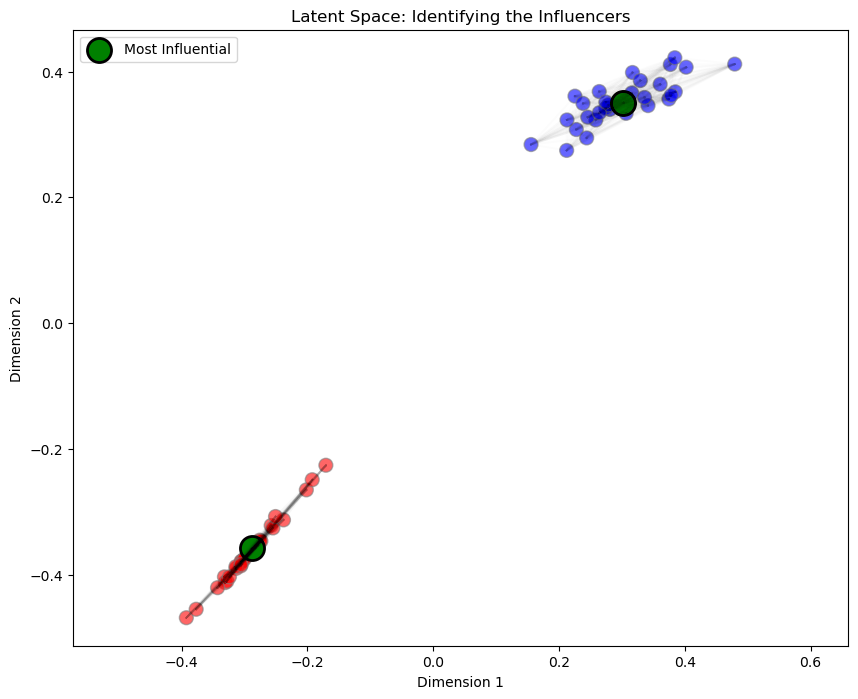

In [20]:
plt.figure(figsize=(10, 8))

# A. Plot all politicians (faded)
colors = ['red' if f == 0 else 'blue' for f in faction]
for u, v in zip(dyad_i, dyad_j):
    if faction[u] == faction[v]: 
        plt.plot([z_post[u, 0], z_post[v, 0]], [z_post[u, 1], z_post[v, 1]],'k-', alpha=0.01)

# Plot the nodes
plt.scatter(z_post[:, 0], z_post[:, 1], c=colors, s=100, edgecolors='gray', alpha=0.6)

# Plot the influential politicians
influentials = [influential_A, influential_B]
plt.scatter(z_post[influentials, 0], z_post[influentials, 1], c='green', s=300, 
            edgecolors='black', linewidth=2, label="Most Influential")

plt.title("Latent Space: Identifying the Influencers")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.axis('equal')
plt.show()

## Q2: Who are the two politicians that are best suited for inter-faction negotiations?

I think the best negotiators are the ones that despite belonging to opposing factions, they occupy positions that are closer to the "other side" and can communcate the best.

**Translation to Latent Space**
- the expected interaction volume drops as distance increases

==> the best pair of negotiators is the dyad(i,j) where i is from faction A and j is from faction B that have the **Minimum Euclidean Distance** in the latent space. (Nodes that are the edge of the cluster pointing to the other faction).


In [21]:
negotiator_A = -1
negatiator_B = -1
min_distance = float('inf')

for i in range(N):
    if faction[i] == 0:  # Faction A
        for j in range(N):
            if faction[j] == 1:  # Faction B
                distance = np.sqrt(np.sum((z_post[i] - z_post[j])**2))
                if distance < min_distance:
                    min_distance = distance
                    negotiator_A = i
                    negotiator_B = j

print(f"Negotiator from Faction A: Node {negotiator_A}")
print(f"Negotiator from Faction B: Node {negotiator_B}")
print(f"Minimum Latent Distance between Negotiators: {min_distance}")

Negotiator from Faction A: Node 5
Negotiator from Faction B: Node 57
Minimum Latent Distance between Negotiators: 0.6054701809618354


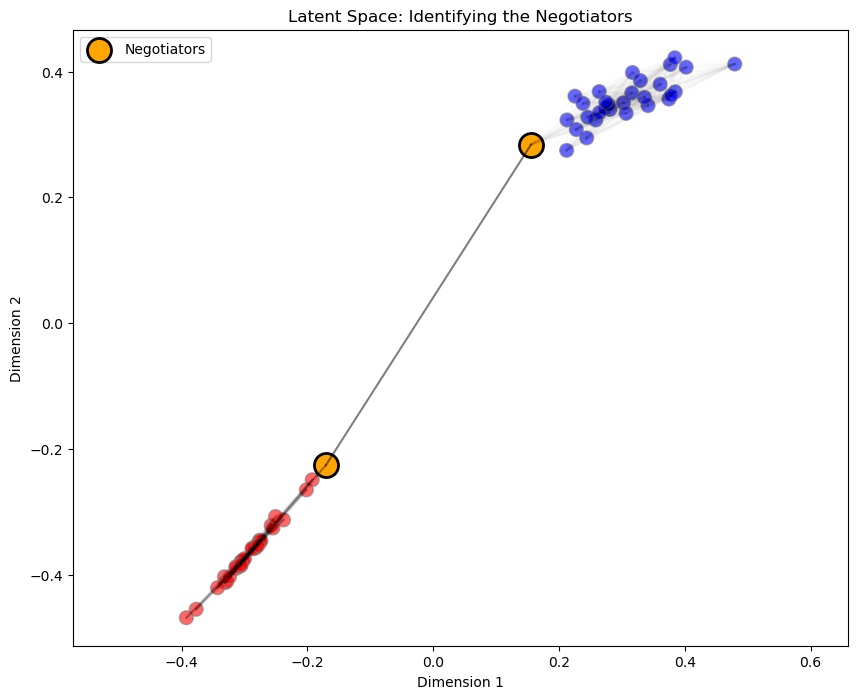

In [27]:
plt.figure(figsize=(10, 8))

# A. Plot all politicians (faded)
colors = ['red' if f == 0 else 'blue' for f in faction]
for u, v in zip(dyad_i, dyad_j):
    if faction[u] == faction[v]: 
        plt.plot([z_post[u, 0], z_post[v, 0]], [z_post[u, 1], z_post[v, 1]],'k-', alpha=0.01)

# Plot the nodes
plt.scatter(z_post[:, 0], z_post[:, 1], c=colors, s=100, edgecolors='gray', alpha=0.6)

# Plot the influential politicians
negotiators = [negotiator_A, negotiator_B]
plt.scatter(z_post[negotiators, 0], z_post[negotiators, 1], c='orange', s=300, 
            edgecolors='black', linewidth=2, label="Negotiators")
plt.plot([z_post[negotiator_A, 0], z_post[negotiator_B, 0]], [z_post[negotiator_A, 1], z_post[negotiator_B, 1]],'k-', alpha=0.5)

plt.title("Latent Space: Identifying the Negotiators")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.axis('equal')
plt.show()

## What happens if the 2 factions are completely separated

- For **Q1** I don't it will change the final result, as everything needed is inside the faction
- FOr **Q2** In the current model communication is already rare between factions (72%zeros). If we break the link the answer in Q2 will transform to **the pair of politicians most likely to communicate**


## Final Answers

- **Q1** : 

    - Most Influential (Faction A): **Node 23**, Messages Sent: 428
    - Most Influential (Faction B): **Node 45**, Messages Sent: 395

- **Q2** :

    - Negotiator from Faction A: **Node 5**
    - Negotiator from Faction B: **Node 57**